In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})

In [2]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, color in enumerate(default_colors):
    print(f"{i}: {color}")

0: #1f77b4
1: #ff7f0e
2: #2ca02c
3: #d62728
4: #9467bd
5: #8c564b
6: #e377c2
7: #7f7f7f
8: #bcbd22
9: #17becf


In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import layers
import losses
import models
import utils

In [5]:
################################################################################
def print_job(
    alpha, beta, criterion, delta, deltaS, epochs, embedding_level, 
    experiments_directory, instance_conv, lr, N_test, N_train, N_val, pooling, 
    save, seed, use_pos_embedding, weight_decay
):
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    #model_name = f"alpha={alpha}_beta={beta}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    
    if os.path.exists(f'{experiments_directory}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_directory}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
    
    command = (
        f"python ../src/toy_data.py "
        f"--alpha={alpha} "
        #f"--beta={beta} "
        f"--batch_size={batch_size} "
        f"--criterion='{criterion}' "
        f"--delta={delta} "
        f"--deltaS={deltaS} "
        f"--epochs={epochs} "
        f"{'--embedding_level ' if embedding_level else ''}"
        f"--experiments_directory='{experiments_directory}' "
        f"{'--instance_conv ' if instance_conv else ''}"
        f"--lr={lr} "
        f"--model_name='{model_name}' "
        f"--N_test={N_test} "
        f"--N_train={N_train} "
        f"--N_val={N_val} "
        f"--pooling='{pooling}' "
        f"{'--save ' if save else ''}"
        f"--seed={seed} "
        f"{'--use_pos_embedding ' if use_pos_embedding else ''}"
        f"--weight_decay={weight_decay}"
    )
    
    print(f'    "{command}"')

In [6]:
# Varying delta
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [1.0]
batch_size = 64
#criterions = ["L1", "L2"]
criterions = ["L1"]
data_seed_test, data_seed_train, data_seed_val = 2, 0, 1
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
deltaS = 3
epochs = 1000
embedding_level = False
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_conv=True_instance_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_embedding_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_retry2" 
instance_conv = True
lrs = [0.1, 0.01, 0.001, 0.0001]
N_train = 400
N_test = 1000
N_val = 100
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["attention"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

#for alpha, criterion, delta, lr, pooling, seed in itertools.product(alphas, criterions, deltas, lrs, poolings, seeds):
for alpha, beta, criterion, delta, lr, pooling, seed in itertools.product(alphas, betas, criterions, deltas, lrs, poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 

    print_job(alpha, beta, criterion, delta, deltaS, epochs, embedding_level,
              temp_experiments_directory, instance_conv, lr, N_test, N_train, N_val, pooling, save, 
              seed, use_pos_embedding, weight_decay)

In [7]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [1.0]
batch_size = 64
#criterions = ["L1", "L2"]
criterions = ["GuidedL1"]
data_seed_test, data_seed_train, data_seed_val = 2, 0, 1
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
deltaS = 3
epochs = 1000
embedding_level = True
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_embedding_level=True_use_pos_embedding=False" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_retry2" 
instance_conv = True
lrs = [0.1, 0.01, 0.001, 0.0001]
N_train = 400
N_test = 1000
N_val = 100
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["attention"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

columns = ["model_name", "Delta", "seed", "test_acc", "test_auroc", "test_auprc", "test_loss", "test_nll", "train_acc", "train_auroc", "train_auprc", "train_loss", "train_nll", "val_acc", "val_auroc", "val_auprc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

#for alpha, criterion, delta, lr, pooling, seed in itertools.product(alphas, criterions, deltas, lrs, poolings, seeds):
for alpha, beta, criterion, delta, lr, pooling, seed in itertools.product(alphas, betas, criterions, deltas, lrs, poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    #model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    model_name = f"alpha={alpha}_beta={beta}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"

    if os.path.exists(f"{temp_experiments_directory}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_directory}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, delta, seed, temp_df.test_acc.values[index], temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_acc.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_acc.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["Delta", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

,model_name,Delta,seed,test_acc,test_auroc,test_auprc,test_loss,test_nll,train_acc,train_auroc,train_auprc,train_loss,train_nll,val_acc,val_auroc,val_auprc,val_loss,val_nll


In [8]:
df.test_auroc.values

array([], dtype=object)

In [9]:
df.model_name.values

array([], dtype=object)

In [11]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [0.0]
batch_size = 64
#criterions = ['L1', 'L2']
criterions = ['L1']
delta = 2.0
deltaS = 3
epochs = 1000
embedding_level = True
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000" 
instance_conv = False
lrs = [0.1, 0.01, 0.001, 0.0001]
N_trains = [100, 158, 251, 398, 630, 1000]#, 1584, 2511, 3981, 6309, 10000]
#N_trains = [1584, 2511, 3981, 6309, 10000]
N_trains = [100000]
N_test = 1000
N_vals = [25, 39, 62, 99, 157, 250]#, 396, 627, 995, 1577, 2500]
#N_vals = [396, 627, 995, 1577, 2500]
N_vals = [25000]
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["transformer"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

#for alpha, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
for alpha, beta, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, betas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    
    print_job(alpha, beta, criterion, delta, deltaS, epochs, embedding_level,
              temp_experiments_directory, instance_conv, lr, N_test, N_train, N_val, pooling, 
              save, seed, use_pos_embedding, weight_decay)

    "python ../src/toy_data.py --alpha=1.0 --batch_size=64 --criterion='L1' --delta=2.0 --deltaS=3 --epochs=1000 --embedding_level --experiments_directory='/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000' --lr=0.1 --model_name='alpha=1.0_criterion=L1_lr=0.1_pooling=transformer_seed=1001_use_pos_embedding=False' --N_test=1000 --N_train=100000 --N_val=25000 --pooling='transformer' --seed=1001 --weight_decay=0.0"
    "python ../src/toy_data.py --alpha=1.0 --batch_size=64 --criterion='L1' --delta=2.0 --deltaS=3 --epochs=1000 --embedding_level --experiments_directory='/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000' --lr=0.01 --model_name='alpha=1.0_criterion=L1_lr=0.01_pooling=transformer_seed=1001_use_pos_em

In [24]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [0.0]
batch_size = 64
#criterions = ["L1", "L2"]
criterions = ["L1"]
delta = 2.0
deltaS = 3
epochs = 1000
embedding_level = True
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_embedding_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_retry3" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000" 
instance_conv = False
lrs = [0.1, 0.01, 0.001, 0.0001]
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
N_trains = [100000]
N_test = 1000
N_vals = [25, 39, 62, 99, 157, 250, 396, 627, 995, 1577, 2500]
N_vals = [25000]
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["transformer"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

columns = ["model_name", "N_train", "seed", "test_acc", "test_auroc", "test_auprc", "test_loss", "test_nll", "train_acc", "train_auroc", "train_auprc", "train_loss", "train_nll", "val_acc", "val_auroc", "val_auprc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

#for alpha, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
for alpha, beta, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, betas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    #model_name = f"alpha={alpha}_beta={beta}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    print(f"{temp_experiments_directory}/{model_name}.csv")
    if os.path.exists(f"{temp_experiments_directory}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_directory}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, N_train, seed, temp_df.test_acc.values[index], temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_acc.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_acc.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["N_train", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.1_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.01_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.001_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1

,model_name,N_train,seed,test_acc,test_auroc,test_auprc,test_loss,test_nll,train_acc,train_auroc,train_auprc,train_loss,train_nll,val_acc,val_auroc,val_auprc,val_loss,val_nll


In [173]:
df.test_auroc.values

array([0.78119999, 0.59381402, 0.69866288, 0.75345886, 0.76159096,
       0.78237629])

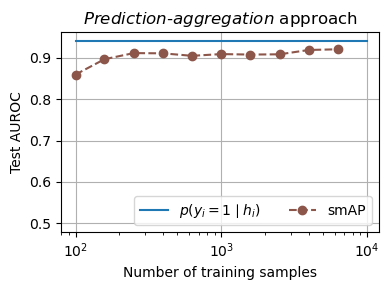

In [7]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288]

# Instance approach data
instance_smap_aurocs = [0.859850, 0.897046, 0.911858, 0.911241, 0.905228, 0.909461, 0.908273, 0.908889, 0.919379, 0.921080]

# Embedding approach data
#embedding_smap_aurocs = [0.825767, 0.886403, 0.885079, 0.891080, 0.894557, 0.909737, 0.910661, 0.913466, 0.916263, 0.916715, 0.915010]

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
ax.plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
ax.plot(N_trains[:-1], instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
ax.plot([100], [0.5], color="#FFFFFF")
ax.set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.set_xlim(80, 12000)
ax.legend(loc="lower right", ncols=2)
ax.grid()

fig.tight_layout()
plt.show()

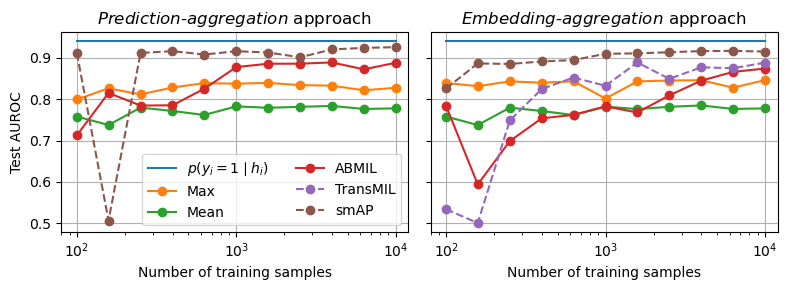

In [8]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742]

# Instance approach data
instance_max_aurocs = [0.79922861, 0.82617551, 0.81138778, 0.82818407, 0.83871472, 0.8374024, 0.83935493, 0.8339535, 0.83258915, 0.82142228, 0.82751989]
instance_mean_aurocs = [0.75799811, 0.73751485, 0.77952754, 0.77141953, 0.76173103, 0.78252029, 0.77914345, 0.78147614, 0.78352463, 0.7763468, 0.77771914]
instance_attention_aurocs = [0.71253049, 0.8149966, 0.78454089, 0.78508896, 0.82515526, 0.8774966, 0.88565868, 0.88576275, 0.88885957, 0.87204719, 0.88799542]
instance_aurocs = [0.54418731, 0.49448657, 0.60938799, 0.90453953, 0.89152825, 0.92568898, 0.92719746, 0.92076778, 0.93211067, 0.93202257, 0.93477529]
instance_smap_aurocs = [0.911241, 0.506472, 0.911557, 0.916131, 0.907932, 0.915906, 0.912798, 0.901223, 0.920220, 0.923949, 0.925693]

# Embedding approach data
embedding_max_aurocs = [0.83920681, 0.83130884, 0.8430478, 0.83972704, 0.84314382, 0.80154121, 0.84288782, 0.84505439, 0.84580052, 0.82786, 0.84583652]
embedding_mean_aurocs = [0.75799805, 0.73737478, 0.77939558, 0.77136952, 0.76157498, 0.78188413, 0.77605063, 0.78147614, 0.78476489, 0.77635074, 0.77766311]
embedding_attention_aurocs = [0.78364861, 0.59374005, 0.69853681, 0.75359094, 0.76203912, 0.78248435, 0.76786065, 0.8089931, 0.84469223, 0.86586171, 0.87401581]
embedding_transformer_aurocs = [0.53374463, 0.50044215, 0.74862361, 0.82435507, 0.85234016, 0.83231711, 0.88865548, 0.84906542, 0.87685645, 0.87486798, 0.8882314]
embedding_smap_aurocs = [0.825767, 0.886403, 0.885079, 0.891080, 0.894557, 0.909737, 0.910661, 0.913466, 0.916263, 0.916715, 0.915010]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
axs[0].plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
axs[0].plot(N_trains, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[0].plot(N_trains, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[0].plot(N_trains, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[0].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(N_trains, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
axs[0].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[0].set_xlabel("Number of training samples")
axs[0].set_ylabel("Test AUROC")
axs[0].set_xscale("log")
axs[0].set_xlim(80, 12000)
axs[0].legend(loc="lower right", ncols=2)
axs[0].grid()

# Embedding approach plot
axs[1].plot(N_trains, bayes_aurocs, color="#1F77B4")
axs[1].plot(N_trains, embedding_max_aurocs, color="#FF7F0E", marker="o")
axs[1].plot(N_trains, embedding_mean_aurocs, color="#2CA02C", marker="o")
axs[1].plot(N_trains, embedding_attention_aurocs, color="#D62728", marker="o")
axs[1].plot(N_trains, embedding_transformer_aurocs, color="#9467BD", linestyle="--", marker="o")
axs[1].plot(N_trains, embedding_smap_aurocs, color="#8C564B", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[1].set_xlabel("Number of training samples")
axs[1].set_xscale("log")
axs[1].set_xlim(80, 12000)
# Remove legend from right plot
axs[1].grid()

fig.tight_layout()
fig.savefig("varying_training_set_size.pdf", bbox_inches="tight")
plt.show()

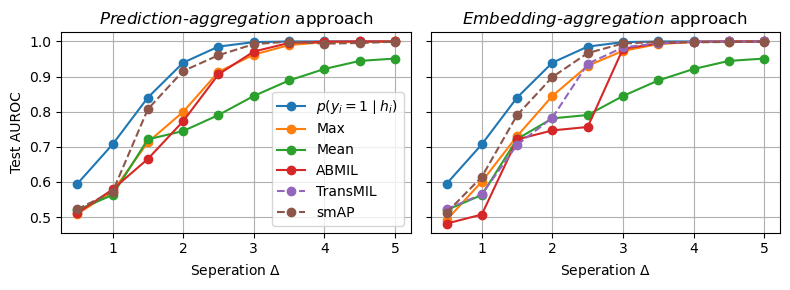

In [6]:
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

instance_bayes_aurocs = [0.5946202278137207, 0.7070890069007874, 0.8402831554412842, 0.9396085739135742, 0.9853242635726929, 0.9980275630950928, 0.9998959302902222, 0.9999998807907104, 0.9999999403953552, 0.9999999403953552]
instance_max_aurocs = [0.50939441, 0.5724225 , 0.71332663, 0.79945076, 0.91336578, 0.96227837, 0.98967338, 0.99791551, 0.9982276 , 0.99998796]
instance_mean_aurocs = [0.51986909, 0.56306016, 0.72127265, 0.74496269, 0.79056633, 0.84471428, 0.88895154, 0.92152393, 0.9445619 , 0.95127153]
instance_attention_aurocs = [0.51072675, 0.57890421, 0.66549838, 0.77291787, 0.90620798, 0.97115672, 0.99573481, 0.99939978, 0.99997991, 0.99999988]
instance_smap_aurocs = [0.522361695766449, 0.5719543695449829, 0.8073667287826538, 0.9158865213394164, 0.9606379270553588, 0.9923421144485474, 0.9994077682495116, 0.9937903881072998, 0.9955028295516968, 0.9992838501930236]

embedding_bayes_aurocs = [0.5946202278137207, 0.7070890069007874, 0.8402831554412842, 0.9396085739135742, 0.9853242635726929, 0.9980275630950928, 0.9998959302902222, 0.9999998807907104, 0.9999999403953552, 0.9999999403953552]
embedding_max_aurocs = [0.49145383, 0.60111392, 0.73047101, 0.84476829, 0.93063831, 0.97298902, 0.99260211, 0.99847162, 0.99980396, 0.99997592]
embedding_mean_aurocs = [0.51998907, 0.56290013, 0.72213286, 0.78105593, 0.79056633, 0.84471625, 0.88895154, 0.92155594, 0.9445619 , 0.95127147]
embedding_attention_aurocs = [0.48145124, 0.50732589, 0.72098058, 0.74676311, 0.7564857, 0.97901058, 0.99417847, 0.99879968, 0.99997592, 0.99999994]
embedding_transformer_aurocs = [0.52236974, 0.56498867, 0.70559061, 0.78284842, 0.93642163, 0.98287159, 0.9947046 , 0.99934787, 0.99987584, 0.99999994]
embedding_smap_aurocs = [0.5123371481895447, 0.6145613193511963, 0.7902123332023621, 0.898664116859436, 0.9668875336647034, 0.9941824674606324, 0.998479664325714, 0.9975714087486268, 0.9985036849975586, 0.9994878768920898]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

axs[0].plot([0.5], [0.5], color="#FFFFFF")
axs[0].plot(deltas, instance_bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
axs[0].plot(deltas, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[0].plot(deltas, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[0].plot(deltas, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[0].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(deltas, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")

axs[0].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[0].set_xlabel(r"Seperation $\Delta$")
axs[0].set_ylabel("Test AUROC")
axs[0].legend(loc="lower right")
axs[0].grid()

axs[1].plot(deltas, embedding_bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
axs[1].plot(deltas, embedding_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[1].plot(deltas, embedding_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[1].plot(deltas, embedding_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[1].plot(deltas, embedding_transformer_aurocs, color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[1].plot(deltas, embedding_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[1].set_xlabel(r"Seperation $\Delta$")
#axs[1].legend(loc="lower right")
axs[1].grid()

fig.tight_layout()
fig.savefig("varying_separation.pdf", bbox_inches="tight")
plt.show()

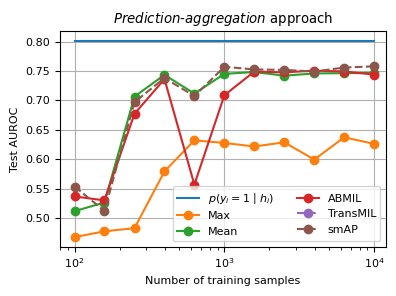

In [6]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989]

# Instance approach data
instance_max_aurocs = [0.4677837491035461, 0.4776943325996399, 0.4829356372356415, 0.5794643759727478, 0.6321178674697876, 0.6276847124099731, 0.6217111349105835, 0.6288169622421265, 0.599441409111023, 0.637269139289856, 0.6261683106422424]
instance_mean_aurocs = [0.5119630694389343, 0.5265707969665527, 0.7065068483352661, 0.7433943152427673, 0.7115781307220459, 0.7450727224349976, 0.7481635212898254, 0.7419298887252808, 0.7457669377326965, 0.746211051940918, 0.7467551231384277]
instance_attention_aurocs = [0.5368334054946899, 0.530153751373291, 0.6773054599761963, 0.7361525297164917, 0.5569846034049988, 0.7087774276733398, 0.7489477396011353, 0.7475473284721375, 0.7505720853805542, 0.7490077614784241, 0.7438783645629883]
instance_smap_aurocs = [0.5535796880722046, 0.5122291445732117, 0.6971125602722168, 0.7379869222640991, 0.7073650360107422, 0.7570938467979431, 0.7525327205657959, 0.7517445087432861, 0.7489997744560242, 0.7557534575462341, 0.7578580379486084]

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
ax.plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
ax.plot(N_trains, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
ax.plot(N_trains, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
ax.plot(N_trains, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
ax.plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
ax.plot(N_trains, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
ax.set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.set_xlim(80, 12000)
ax.legend(loc="lower right", ncols=2)
ax.grid()

fig.tight_layout()
fig.savefig("varying_training_set_size.pdf", bbox_inches="tight")
plt.show()